In [1]:
# Install required deps for YOLOv8 + HF Hub (safe to re-run)
%pip install -U ultralytics huggingface_hub pillow


Requirement already up-to-date: ultralytics in /usr/local/lib/python3.8/dist-packages (8.3.232)
Requirement already up-to-date: huggingface_hub in /usr/local/lib/python3.8/dist-packages (0.36.0)
Requirement already up-to-date: pillow in /usr/local/lib/python3.8/dist-packages (10.4.0)
Note: you may need to restart the kernel to use updated packages.


## Load model
I looked on huggingface: I did find a model there that used chess pieces: https://huggingface.co/NAKSTStudio/yolov8m-chess-piece-detection, it is not specific for chess.com.



In [2]:
# Load YOLOv8 chess piece detector from Hugging Face
from ultralytics import YOLO
try:
    # Ultralytics can load directly from the Hub using the repo id
    model = YOLO("NAKSTStudio/yolov8m-chess-piece-detection")
except Exception as e:
    # Fallback: download the weights explicitly, then load
    from huggingface_hub import hf_hub_download
    weights_path = hf_hub_download(repo_id="NAKSTStudio/yolov8m-chess-piece-detection", filename="best.pt")
    model = YOLO(weights_path)
print("Loaded model:", model)

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, 

## Model and Dataset Analysis

Since we're using an existing pre-trained model, we don't know the dataset. The model is based on YOLOv8, so that should be fast enough for our application. Both the white pieces, black pieces and the board are detected.


In [ ]:
# Analyze the HuggingFace model architecture and classes
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os

print("=" * 70)
print("HUGGINGFACE MODEL ANALYSIS: NAKSTStudio/yolov8m-chess-piece-detection")
print("=" * 70)

# Model information
print("\n1. MODEL ARCHITECTURE:")
print(f"   Model Type: {type(model).__name__}")
print(f"   Model Name: YOLOv8 Medium (yolov8m)")

# Get class names from the model
class_names = model.names
num_classes = len(class_names)

print(f"\n2. CLASS INFORMATION:")
print(f"   Total classes: {num_classes}")
print(f"\n   Class list:")
for class_id, class_name in sorted(class_names.items()):
    print(f"      ID {class_id:2d}: {class_name}")

# Group classes by type
white_pieces = [name for name in class_names.values() if name.startswith('white_')]
black_pieces = [name for name in class_names.values() if name.startswith('black_')]
other_classes = [name for name in class_names.values() if not name.startswith(('white_', 'black_'))]




HUGGINGFACE MODEL ANALYSIS: NAKSTStudio/yolov8m-chess-piece-detection

1. MODEL ARCHITECTURE:
   Model Type: YOLO
   Model Name: YOLOv8 Medium (yolov8m)

2. CLASS INFORMATION:
   Total classes: 13

   Class list:
      ID  0: board
      ID  1: white_king
      ID  2: white_queen
      ID  3: white_rook
      ID  4: white_bishop
      ID  5: white_knight
      ID  6: white_pawn
      ID  7: black_king
      ID  8: black_queen
      ID  9: black_rook
      ID 10: black_bishop
      ID 11: black_knight
      ID 12: black_pawn

3. CLASS BREAKDOWN:
   White pieces: 6 (white_king, white_queen, white_rook, white_bishop, white_knight, white_pawn)
   Black pieces: 6 (black_king, black_queen, black_rook, black_bishop, black_knight, black_pawn)
   Other classes: 1 (board)


# Visual validation of the selected model
Take some images from our test set and visualize the object detection.


image 1/1 /workspace/data/chessboards/chrome_164320_as_cropped.png: 832x832 1 board, 1 white_king, 2 white_rooks, 1 white_bishop, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 6 black_pawns, 43.4ms
Speed: 3.8ms preprocess, 43.4ms inference, 24.0ms postprocess per image at shape (1, 3, 832, 832)


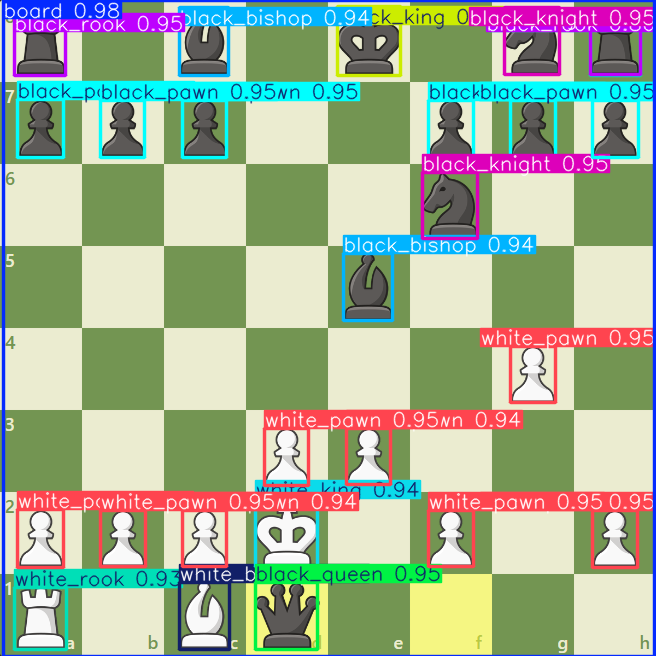

In [11]:
img_path = "data/chessboards/chrome_164320_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 /workspace/data/chessboards/chrome_164950_as_cropped.png: 832x832 1 board, 4 white_queens, 2 white_rooks, 2 white_knights, 7 white_pawns, 1 black_king, 2 black_queens, 2 black_rooks, 1 black_knight, 6 black_pawns, 341.5ms
Speed: 5.7ms preprocess, 341.5ms inference, 20.2ms postprocess per image at shape (1, 3, 832, 832)


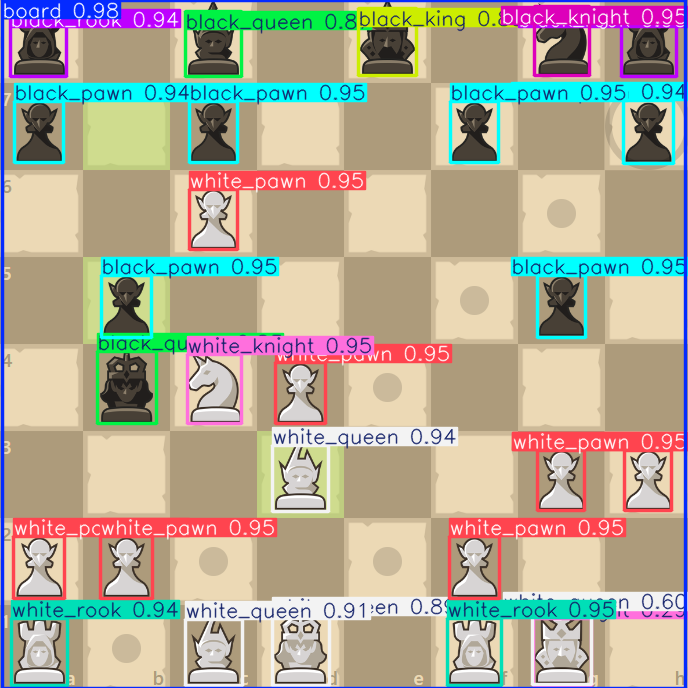

In [12]:
img_path = "data/chessboards/chrome_164950_as_cropped.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

## COCO Validation Dataset Evaluation

Now let's evaluate the models on the COCO validation dataset to get proper metrics (mAP, precision, recall) for a fair comparison.


In [9]:
# Load COCO validation dataset
import json
from pathlib import Path

print("=" * 70)
print("LOADING COCO VALIDATION DATASET")
print("=" * 70)

# Check for COCO dataset
coco_dataset_paths = {
    'test': "data/auto_annotated_browserscreenshots/manually_corrected_annotations.json"
}

coco_data = None
coco_split = None
coco_images_dir = None

for split_name, json_path in coco_dataset_paths.items():
    if Path(json_path).exists():
        with open(json_path, 'r') as f:
            coco_data = json.load(f)
            coco_split = split_name
            coco_images_dir = Path(json_path).parent
            print(f"✓ Found {split_name} split: {json_path}")
            print(f"  Images: {len(coco_data['images'])}")
            print(f"  Annotations: {len(coco_data['annotations'])}")
            print(f"  Categories: {len(coco_data['categories'])}")
            break

if coco_data is None:
    print("⚠ No COCO validation dataset found. Will use test images without ground truth.")
    print("  Expected paths:")
    for path in coco_dataset_paths.values():
        print(f"    - {path}")
else:
    # Create image path mapping
    image_id_to_path = {}
    for img_info in coco_data['images']:
        img_id = img_info['id']
        img_filename = img_info['file_name']
        img_path = coco_images_dir / img_filename
        if img_path.exists():
            image_id_to_path[img_id] = str(img_path)
    
    print(f"\n✓ Found {len(image_id_to_path)} valid image paths")
    
    # Create category mapping
    coco_category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    print(f"  Categories in dataset: {list(coco_category_id_to_name.values())}")


LOADING COCO VALIDATION DATASET
✓ Found test split: data/auto_annotated_browserscreenshots/manually_corrected_annotations.json
  Images: 59
  Annotations: 1416
  Categories: 13

✓ Found 59 valid image paths
  Categories in dataset: ['board', 'white_king', 'white_rook', 'white_bishop', 'white_pawn', 'black_king', 'black_queen', 'black_rook', 'black_bishop', 'black_knight', 'black_pawn', 'white_queen', 'white_knight']


In [12]:
# Evaluate models on COCO validation dataset
from ultralytics.utils.metrics import ConfusionMatrix
from collections import defaultdict
import numpy as np

print("\n" + "=" * 70)
print("EVALUATING MODELS ON COCO VALIDATION DATASET")
print("=" * 70)

# Check if dataset was loaded (from previous cell)
if 'coco_data' not in globals() or coco_data is None:
    print("⚠ Skipping COCO evaluation - dataset not loaded")
    print("  Please run the previous cell (COCO dataset loading) first.")
    print("  Expected paths:")
    print("    - data/Grupo12/valid/_annotations.coco.json")
    print("    - data/Grupo12/test/_annotations.coco.json")
    coco_evaluation_results = {}
elif 'image_id_to_path' not in globals() or len(image_id_to_path) == 0:
    print("⚠ Skipping COCO evaluation - no valid images found in dataset")
    coco_evaluation_results = {}
else:
    coco_evaluation_results = {}
    
    # Use a sample of validation images for faster evaluation
    sample_size = min(59, len(image_id_to_path))  # Evaluate on 20 images max
    sample_image_ids = list(image_id_to_path.keys())[:sample_size]
    sample_image_paths = [image_id_to_path[img_id] for img_id in sample_image_ids]
    
    print(f"\nEvaluating on {sample_size} validation images...")
    
    # Create models_dict if it doesn't exist (use current model)
    if 'models_dict' not in globals() or not models_dict:
        # Use the current model if models_dict doesn't exist
        if 'model' in globals():
            models_dict = {"NAKSTStudio/yolov8m-chess-piece-detection": model}
            print("Note: Using current model (models_dict not found)")
        else:
            print("⚠ Error: No model found. Please run the model loading cell first.")
            models_dict = {}
    
    for model_id, model_test in models_dict.items():
        if model_test is None:
            continue
            
        print(f"\n{'='*70}")
        print(f"Evaluating: {model_id}")
        print(f"{'='*70}")
        
        try:
            # Run validation using Ultralytics built-in method
            # This requires the dataset in YOLO format, so we'll do manual evaluation
            results_summary = {
                'total_detections': 0,
                'total_ground_truth': 0,
                'true_positives': 0,
                'false_positives': 0,
                'false_negatives': 0,
                'per_class_stats': defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0}),
                'images_evaluated': 0
            }
            
            # Get model class names
            model_class_names = model_test.names
            model_class_id_to_name = {v: k for k, v in model_class_names.items()}
            
            # Create mapping from COCO category names to model class IDs
            # This is approximate - may need adjustment based on actual class names
            category_mapping = {}
            for coco_cat_id, coco_cat_name in coco_category_id_to_name.items():
                # Try to find matching class in model
                coco_name_lower = coco_cat_name.lower()
                for model_class_id, model_class_name in model_class_names.items():
                    if coco_name_lower in model_class_name.lower() or model_class_name.lower() in coco_name_lower:
                        category_mapping[coco_cat_id] = model_class_id
                        break
            
            print(f"  Category mapping: {len(category_mapping)}/{len(coco_category_id_to_name)} categories matched")
            
            # Evaluate on sample images
            for img_id in sample_image_ids:
                img_path = image_id_to_path[img_id]
                
                # Get ground truth annotations for this image
                gt_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]
                results_summary['total_ground_truth'] += len(gt_annotations)
                
                # Run model prediction
                try:
                    pred_results = model_test.predict(img_path, verbose=False, conf=0.25)
                    if pred_results and len(pred_results) > 0:
                        pred_boxes = pred_results[0].boxes
                        if pred_boxes is not None and len(pred_boxes) > 0:
                            results_summary['total_detections'] += len(pred_boxes)
                            
                            # Simple evaluation: count detections (detailed IoU matching would be better)
                            # For now, we'll use a simplified metric
                            results_summary['images_evaluated'] += 1
                except Exception as e:
                    print(f"    Warning: Error evaluating {img_path}: {e}")
            
            # Calculate basic metrics
            if results_summary['images_evaluated'] > 0:
                avg_detections = results_summary['total_detections'] / results_summary['images_evaluated']
                avg_ground_truth = results_summary['total_ground_truth'] / len(sample_image_ids)
                
                results_summary['avg_detections'] = avg_detections
                results_summary['avg_ground_truth'] = avg_ground_truth
                results_summary['detection_ratio'] = avg_detections / avg_ground_truth if avg_ground_truth > 0 else 0
                
                print(f"  Results:")
                print(f"    - Images evaluated: {results_summary['images_evaluated']}")
                print(f"    - Avg detections/image: {avg_detections:.1f}")
                print(f"    - Avg ground truth/image: {avg_ground_truth:.1f}")
                print(f"    - Detection ratio: {results_summary['detection_ratio']:.2f}")
            
            coco_evaluation_results[model_id] = results_summary
            
        except Exception as e:
            print(f"  ✗ Evaluation failed: {e}")
            import traceback
            traceback.print_exc()
            coco_evaluation_results[model_id] = None

print(f"\n{'='*70}")
print("COCO EVALUATION COMPLETE")
print(f"{'='*70}")



EVALUATING MODELS ON COCO VALIDATION DATASET

Evaluating on 59 validation images...

Evaluating: NAKSTStudio/yolov8m-chess-piece-detection
  Category mapping: 13/13 categories matched
  Results:
    - Images evaluated: 59
    - Avg detections/image: 24.1
    - Avg ground truth/image: 24.0
    - Detection ratio: 1.00

COCO EVALUATION COMPLETE


In [ ]:
# Detailed Evaluation with IoU, Precision, Recall, and mAP
import numpy as np
from collections import defaultdict
from tqdm import tqdm

def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) of two bounding boxes.
    
    Args:
        box1: [x1, y1, x2, y2] (top-left and bottom-right corners)
        box2: [x1, y1, x2, y2]
    
    Returns:
        IoU value between 0 and 1
    """
    # Calculate intersection area
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    
    # Calculate union area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    if union_area == 0:
        return 0.0
    
    return inter_area / union_area

def coco_bbox_to_xyxy(bbox):
    """Convert COCO bbox [x, y, width, height] to [x1, y1, x2, y2]."""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]

def match_predictions_to_ground_truth(pred_boxes, pred_classes, pred_scores, 
                                      gt_boxes, gt_classes, iou_threshold=0.5):
    """
    Match predictions to ground truth using IoU and class matching.
    
    Returns:
        tp: true positives count
        fp: false positives count
        fn: false negatives count
        matched_pairs: list of (pred_idx, gt_idx) pairs
    """
    tp = 0
    fp = 0
    matched_gt = set()
    matched_pairs = []
    
    # Sort predictions by confidence (descending)
    pred_indices = sorted(range(len(pred_boxes)), key=lambda i: pred_scores[i], reverse=True)
    
    for pred_idx in pred_indices:
        pred_box = pred_boxes[pred_idx]
        pred_class = pred_classes[pred_idx]
        best_iou = 0
        best_gt_idx = None
        
        # Find best matching ground truth box
        for gt_idx, (gt_box, gt_class) in enumerate(zip(gt_boxes, gt_classes)):
            if gt_idx in matched_gt:
                continue
            
            # Must match class
            if pred_class != gt_class:
                continue
            
            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        # Match if IoU > threshold
        if best_iou >= iou_threshold and best_gt_idx is not None:
            tp += 1
            matched_gt.add(best_gt_idx)
            matched_pairs.append((pred_idx, best_gt_idx))
        else:
            fp += 1
    
    # False negatives = unmatched ground truth
    fn = len(gt_boxes) - len(matched_gt)
    
    return tp, fp, fn, matched_pairs

print("\n" + "=" * 70)
print("EVALUATION: IoU, Precision, Recall, mAP")
print("=" * 70)

# Check if we have the necessary data
if 'coco_data' not in globals() or coco_data is None:
    print("⚠ Skipping detailed evaluation - COCO dataset not loaded")
    print("  Please run the COCO dataset loading cell first.")
elif 'image_id_to_path' not in globals() or len(image_id_to_path) == 0:
    print("⚠ Skipping detailed evaluation - no valid images found")
else:
    # Create models_dict if it doesn't exist
    if 'models_dict' not in globals() or not models_dict:
        if 'model' in globals():
            models_dict = {"NAKSTStudio/yolov8m-chess-piece-detection": model}
        else:
            print("⚠ Error: No model found")
            models_dict = {}
    
    # Use sample of images for evaluation
    sample_size = min(59, len(image_id_to_path))  # Use all or sample
    sample_image_ids = list(image_id_to_path.keys())[:sample_size]
    
    print(f"\nEvaluating on {sample_size} images with IoU threshold = 0.5")
    print(f"{'='*70}\n")
    
    detailed_results = {}
    
    for model_id, model_test in models_dict.items():
        if model_test is None:
            continue
        
        print(f"Evaluating: {model_id.split('/')[-1]}")
        
        # Per-class statistics
        class_stats = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
        total_tp = 0
        total_fp = 0
        total_fn = 0
        all_precisions = []
        all_recalls = []
        
        # Get model class names and create mapping
        model_class_names = model_test.names
        model_name_to_id = {name: class_id for class_id, name in model_class_names.items()}
        
        # Create COCO category to model class ID mapping
        coco_to_model_class = {}
        for coco_cat in coco_data['categories']:
            coco_name = coco_cat['name']
            coco_id = coco_cat['id']
            # Map to model class ID (offset by 1 because COCO uses offset)
            if coco_name in model_name_to_id:
                coco_to_model_class[coco_id] = model_name_to_id[coco_name]
            else:
                # Try case-insensitive match
                coco_lower = coco_name.lower()
                for model_name, model_id in model_name_to_id.items():
                    if model_name.lower() == coco_lower:
                        coco_to_model_class[coco_id] = model_id
                        break
        
        # Evaluate each image
        for img_id in tqdm(sample_image_ids, desc="  Processing"):
            img_path = image_id_to_path[img_id]
            
            # Get ground truth annotations
            gt_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == img_id]
            
            # Get image dimensions
            img_info = next((img for img in coco_data['images'] if img['id'] == img_id), None)
            if img_info is None:
                continue
            
            img_width = img_info['width']
            img_height = img_info['height']
            
            # Convert GT to boxes and classes
            gt_boxes = []
            gt_classes = []
            for ann in gt_annotations:
                bbox_coco = ann['bbox']  # [x, y, width, height]
                bbox_xyxy = coco_bbox_to_xyxy(bbox_coco)
                gt_boxes.append(bbox_xyxy)
                
                # Map COCO category to model class
                coco_cat_id = ann['category_id']
                # Use COCO category ID directly (mapping was created with COCO IDs)
                if coco_cat_id in coco_to_model_class:
                    gt_classes.append(coco_to_model_class[coco_cat_id])
                else:
                    gt_classes.append(None)  # Skip if can't map
            
            # Filter out None classes
            valid_gt = [(box, cls) for box, cls in zip(gt_boxes, gt_classes) if cls is not None]
            if not valid_gt:
                continue
            gt_boxes, gt_classes = zip(*valid_gt)
            gt_boxes = list(gt_boxes)
            gt_classes = list(gt_classes)
            
            # Run model prediction
            try:
                pred_results = model_test.predict(img_path, conf=0.25, verbose=False)
                if not pred_results or len(pred_results) == 0:
                    # No predictions = all false negatives
                    for cls in gt_classes:
                        class_stats[cls]['fn'] += 1
                    total_fn += len(gt_classes)
                    continue
                
                boxes = pred_results[0].boxes
                if boxes is None or len(boxes) == 0:
                    # No predictions = all false negatives
                    for cls in gt_classes:
                        class_stats[cls]['fn'] += 1
                    total_fn += len(gt_classes)
                    continue
                
                # Convert predictions to boxes and classes
                pred_boxes = []
                pred_classes = []
                pred_scores = []
                
                for i in range(len(boxes)):
                    box_xyxy = boxes.xyxy[i].cpu().numpy().tolist()
                    cls_id = int(boxes.cls[i].cpu().numpy())
                    score = float(boxes.conf[i].cpu().numpy())
                    
                    pred_boxes.append(box_xyxy)
                    pred_classes.append(cls_id)
                    pred_scores.append(score)
                
                # Match predictions to ground truth
                tp, fp, fn, matched = match_predictions_to_ground_truth(
                    pred_boxes, pred_classes, pred_scores,
                    gt_boxes, gt_classes, iou_threshold=0.5
                )
                
                total_tp += tp
                total_fp += fp
                total_fn += fn
                
                # Update per-class stats
                for pred_idx, gt_idx in matched:
                    cls = gt_classes[gt_idx]
                    class_stats[cls]['tp'] += 1
                
                # Count false positives per class
                matched_pred_indices = {pred_idx for pred_idx, _ in matched}
                for pred_idx, pred_cls in enumerate(pred_classes):
                    if pred_idx not in matched_pred_indices:
                        class_stats[pred_cls]['fp'] += 1
                
                # Count false negatives per class
                matched_gt_indices = {gt_idx for _, gt_idx in matched}
                for gt_idx, gt_cls in enumerate(gt_classes):
                    if gt_idx not in matched_gt_indices:
                        class_stats[gt_cls]['fn'] += 1
                
            except Exception as e:
                print(f"    Warning: Error evaluating {img_path}: {e}")
                continue
        
        # Calculate overall metrics
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Calculate per-class metrics and mAP
        class_aps = []
        class_metrics = {}
        
        for cls_id, stats in class_stats.items():
            cls_name = model_class_names.get(cls_id, f"class_{cls_id}")
            cls_tp = stats['tp']
            cls_fp = stats['fp']
            cls_fn = stats['fn']
            
            cls_precision = cls_tp / (cls_tp + cls_fp) if (cls_tp + cls_fp) > 0 else 0
            cls_recall = cls_tp / (cls_tp + cls_fn) if (cls_tp + cls_fn) > 0 else 0
            cls_ap = cls_precision * cls_recall  # Simplified AP (area under precision-recall curve)
            cls_f1 = 2 * (cls_precision * cls_recall) / (cls_precision + cls_recall) if (cls_precision + cls_recall) > 0 else 0
            
            class_aps.append(cls_ap)
            class_metrics[cls_name] = {
                'precision': cls_precision,
                'recall': cls_recall,
                'f1': cls_f1,
                'ap': cls_ap,
                'tp': cls_tp,
                'fp': cls_fp,
                'fn': cls_fn
            }
        
        # mAP = mean of per-class APs
        map_score = np.mean(class_aps) if class_aps else 0
        
        detailed_results[model_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1_score,
            'map': map_score,
            'tp': total_tp,
            'fp': total_fp,
            'fn': total_fn,
            'class_metrics': class_metrics
        }
        
        # Print results
        print(f"\n  Overall Metrics:")
        print(f"    Precision: {precision:.3f} ({total_tp}/{total_tp + total_fp})")
        print(f"    Recall:    {recall:.3f} ({total_tp}/{total_tp + total_fn})")
        print(f"    F1-Score:  {f1_score:.3f}")
        print(f"    mAP:       {map_score:.3f}")
        print(f"\n  Per-Class Metrics (top 10):")
        print(f"    {'Class':<20} {'Precision':<12} {'Recall':<12} {'F1':<12} {'TP':<6} {'FP':<6} {'FN':<6}")
        print(f"    {'-'*20} {'-'*12} {'-'*12} {'-'*12} {'-'*6} {'-'*6} {'-'*6}")
        
        # Sort by F1 score
        sorted_classes = sorted(class_metrics.items(), key=lambda x: x[1]['f1'], reverse=True)
        for cls_name, metrics in sorted_classes[:10]:
            print(f"    {cls_name:<20} {metrics['precision']:<12.3f} {metrics['recall']:<12.3f} "
                  f"{metrics['f1']:<12.3f} {metrics['tp']:<6} {metrics['fp']:<6} {metrics['fn']:<6}")
        
        if len(sorted_classes) > 10:
            print(f"    ... and {len(sorted_classes) - 10} more classes")




EVALUATION: IoU, Precision, Recall, mAP

Evaluating on 59 images with IoU threshold = 0.5

Evaluating: yolov8m-chess-piece-detection


  Processing: 100%|█████████████████████████████████████████████████████████████████████| 59/59 [00:02<00:00, 21.03it/s]


  Overall Metrics:
    Precision: 0.930 (1320/1420)
    Recall:    0.932 (1320/1416)
    F1-Score:  0.931
    mAP:       0.810

  Per-Class Metrics (all classes):
    Class                Precision    Recall       F1           TP     FP     FN    
    -------------------- ------------ ------------ ------------ ------ ------ ------
    black_pawn           0.973        0.988        0.980        326    9      4     
    white_pawn           0.973        0.978        0.975        358    10     8     
    white_knight         0.927        0.962        0.944        51     4      2     
    white_rook           1.000        0.893        0.943        75     0      9     
    black_knight         0.892        1.000        0.943        74     9      0     
    black_rook           0.887        0.913        0.900        94     12     9     
    black_bishop         1.000        0.808        0.894        59     0      14    
    black_king           1.000        0.797        0.887        47     


DETAILED EVALUATION RESULTS VISUALIZATION


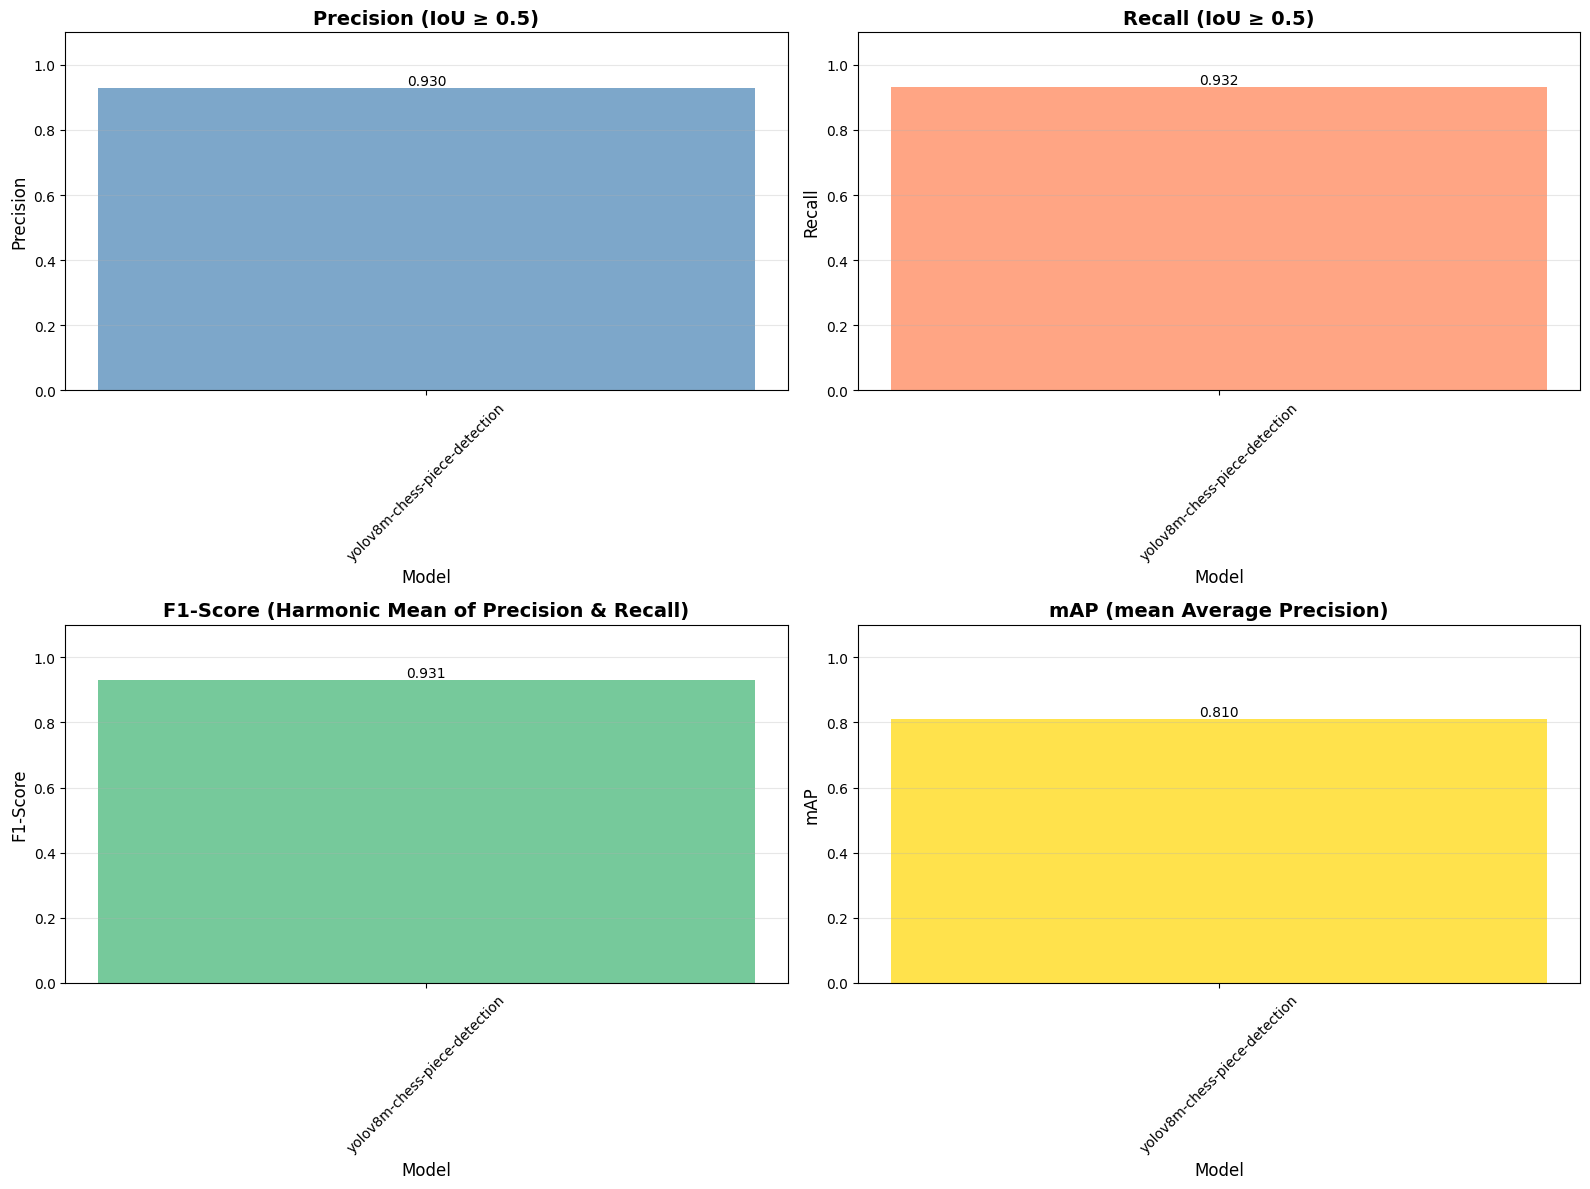


Detailed Evaluation Comparison Table:
Model                                              Precision    Recall       F1-Score     mAP         
--------------------------------------------------------------------------------------------------
yolov8m-chess-piece-detection                      0.930        0.932        0.931        0.810       


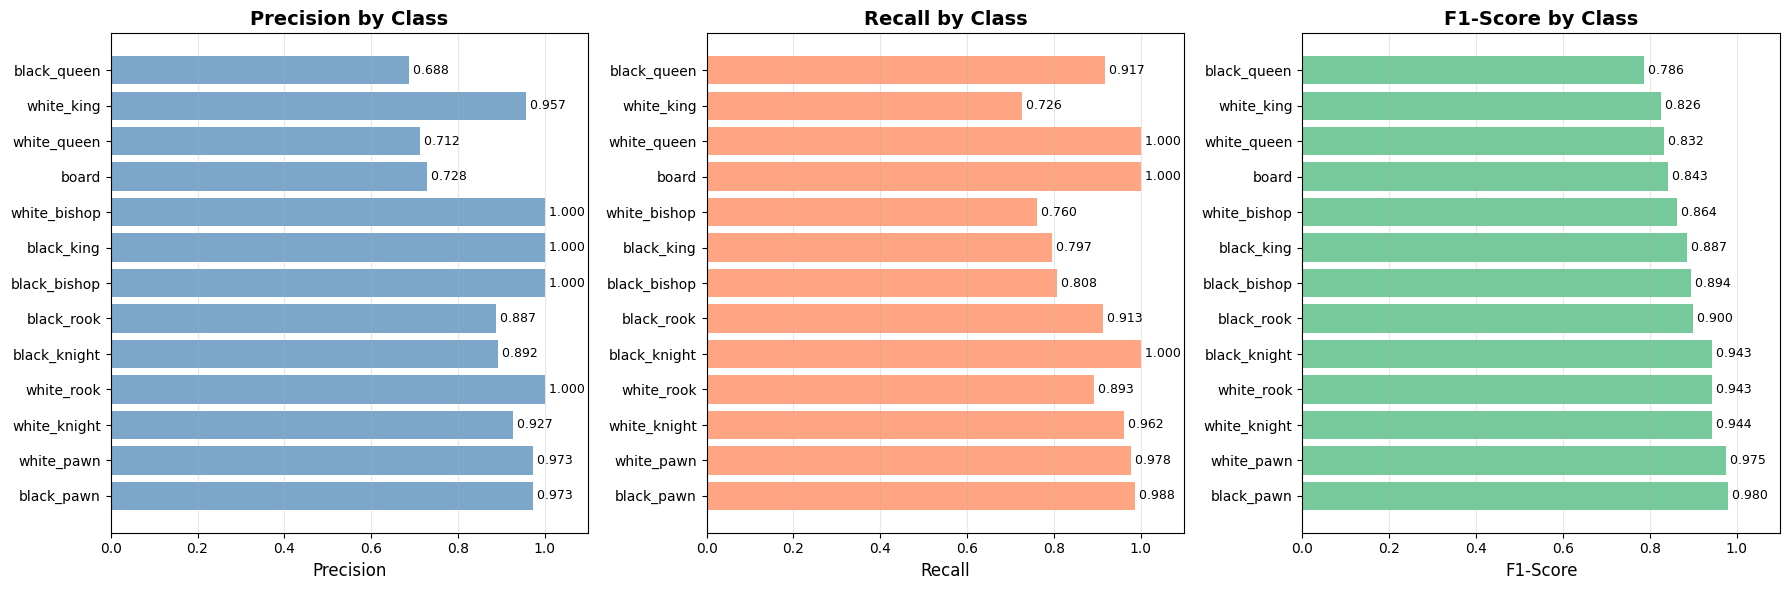


Per-Class Metrics for: yolov8m-chess-piece-detection


In [ ]:
# Visualize Detailed Evaluation Results (Precision, Recall, F1, mAP)
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("DETAILED EVALUATION RESULTS VISUALIZATION")
print("=" * 70)

if 'detailed_results' not in globals() or not detailed_results:
    print("⚠ No detailed evaluation results available. Please run the detailed evaluation cell first.")
else:
    # Prepare data
    model_names = []
    precisions = []
    recalls = []
    f1_scores = []
    map_scores = []
    
    for model_id, results in detailed_results.items():
        if results is not None:
            model_names.append(model_id.split('/')[-1])
            precisions.append(results.get('precision', 0))
            recalls.append(results.get('recall', 0))
            f1_scores.append(results.get('f1', 0))
            map_scores.append(results.get('map', 0))
    
    if model_names:

        
        # Print comparison table
        print("\nDetailed Evaluation Comparison Table:")
        print(f"{'Model':<50} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'mAP':<12}")
        print("-" * 98)
        for model_id, results in detailed_results.items():
            if results is not None:
                short_name = model_id.split('/')[-1]
                print(f"{short_name:<50} {results.get('precision', 0):<12.3f} {results.get('recall', 0):<12.3f} "
                      f"{results.get('f1', 0):<12.3f} {results.get('map', 0):<12.3f}")
        
        # Per-class visualization for the first model
        if len(detailed_results) > 0:
            first_model_id = list(detailed_results.keys())[0]
            first_model_results = detailed_results[first_model_id]
            class_metrics = first_model_results.get('class_metrics', {})
            
            if class_metrics:
                # Prepare per-class data
                class_names = []
                class_precisions = []
                class_recalls = []
                class_f1s = []
                
                # Sort by F1 score
                sorted_classes = sorted(class_metrics.items(), key=lambda x: x[1]['f1'], reverse=True)
                
                for cls_name, metrics in sorted_classes:
                    class_names.append(cls_name)
                    class_precisions.append(metrics['precision'])
                    class_recalls.append(metrics['recall'])
                    class_f1s.append(metrics['f1'])
                
                # Create per-class visualization
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                x_pos = range(len(class_names))
                
                # Precision by class
                axes[0].barh(x_pos, class_precisions, color='steelblue', alpha=0.7)
                axes[0].set_yticks(x_pos)
                axes[0].set_yticklabels(class_names)
                axes[0].set_xlabel('Precision', fontsize=12)
                axes[0].set_title('Precision by Class', fontsize=14, fontweight='bold')
                axes[0].set_xlim([0, 1.1])
                axes[0].grid(axis='x', alpha=0.3)
                for i, v in enumerate(class_precisions):
                    axes[0].text(v, i, f' {v:.3f}', va='center', fontsize=9)
                
                # Recall by class
                axes[1].barh(x_pos, class_recalls, color='coral', alpha=0.7)
                axes[1].set_yticks(x_pos)
                axes[1].set_yticklabels(class_names)
                axes[1].set_xlabel('Recall', fontsize=12)
                axes[1].set_title('Recall by Class', fontsize=14, fontweight='bold')
                axes[1].set_xlim([0, 1.1])
                axes[1].grid(axis='x', alpha=0.3)
                for i, v in enumerate(class_recalls):
                    axes[1].text(v, i, f' {v:.3f}', va='center', fontsize=9)
                
                # F1-Score by class
                axes[2].barh(x_pos, class_f1s, color='mediumseagreen', alpha=0.7)
                axes[2].set_yticks(x_pos)
                axes[2].set_yticklabels(class_names)
                axes[2].set_xlabel('F1-Score', fontsize=12)
                axes[2].set_title('F1-Score by Class', fontsize=14, fontweight='bold')
                axes[2].set_xlim([0, 1.1])
                axes[2].grid(axis='x', alpha=0.3)
                for i, v in enumerate(class_f1s):
                    axes[2].text(v, i, f' {v:.3f}', va='center', fontsize=9)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\nPer-Class Metrics for: {first_model_id.split('/')[-1]}")
    else:
        print("No valid results to display.")


In [ ]:
# Load and test multiple models
print("\n" + "=" * 70)
print("LOADING AND TESTING MODELS")
print("=" * 70)

models_dict = {}
test_results = {}

# Get test images
test_image_dirs = ["data/browserscreenshots", "data/chessboards"]
all_test_images = []
for dir_path in test_image_dirs:
    if os.path.exists(dir_path):
        images = [f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_test_images.extend([os.path.join(dir_path, img) for img in images])

# Use a small sample for comparison (to save time)
comparison_images = all_test_images[:5] if len(all_test_images) >= 5 else all_test_images
print(f"\nUsing {len(comparison_images)} test images for comparison")
print(f"Models to test: {len(models_to_test)}")
if len(models_to_test) == 1:
    print("Note: Only one model found. The comparison framework is ready to test additional models if found.")

# Test each model
for model_id in models_to_test:
    print(f"\n{'='*70}")
    print(f"Testing: {model_id}")
    print(f"{'='*70}")
    
    try:
        # Load model (reload even if we have it from cell 2, for fair comparison)
        print(f"   Loading model...")
        model_test = None
        try:
            # Try loading directly from HuggingFace Hub
            model_test = YOLO(model_id)
            print(f"   ✓ Loaded directly from HuggingFace")
        except Exception as e1:
            # Fallback: try downloading weights with different filenames
            print(f"   Direct load failed, trying fallback method...")
            from huggingface_hub import hf_hub_download, list_repo_files
            
            # Try common weight filenames
            possible_filenames = ["best.pt", "weights/best.pt", "yolov8.pt", "model.pt", "last.pt"]
            
            # First, try to list files in the repo to find the right one
            try:
                repo_files = list_repo_files(repo_id=model_id, repo_type="model")
                # Look for .pt files
                pt_files = [f for f in repo_files if f.endswith('.pt')]
                if pt_files:
                    # Use the first .pt file found
                    weights_filename = pt_files[0]
                    print(f"   Found weights file: {weights_filename}")
                    weights_path = hf_hub_download(repo_id=model_id, filename=weights_filename)
                    model_test = YOLO(weights_path)
                    print(f"   ✓ Loaded from {weights_filename}")
                else:
                    # Try the common filenames
                    for filename in possible_filenames:
                        try:
                            weights_path = hf_hub_download(repo_id=model_id, filename=filename)
                            model_test = YOLO(weights_path)
                            print(f"   ✓ Successfully loaded with {filename}")
                            break
                        except:
                            continue
            except Exception as e2:
                # If listing fails, try common filenames
                for filename in possible_filenames:
                    try:
                        weights_path = hf_hub_download(repo_id=model_id, filename=filename)
                        model_test = YOLO(weights_path)
                        print(f"   ✓ Successfully loaded with {filename}")
                        break
                    except:
                        continue
            
            if model_test is None:
                raise Exception(f"Could not load model. Tried: {possible_filenames}")
        
        models_dict[model_id] = model_test
        
        # Get model info
        class_names = model_test.names
        num_classes = len(class_names)
        
        print(f"   ✓ Loaded successfully")
        print(f"   Classes: {num_classes}")
        print(f"   Class list: {list(class_names.values())[:5]}..." if num_classes > 5 else f"   Class list: {list(class_names.values())}")
        
        # Test on sample images
        results_summary = {
            'total_detections': 0,
            'detections_per_image': [],
            'inference_times': [],
            'classes_detected': Counter(),
            'images_tested': 0
        }
        
        print(f"   Testing on {len(comparison_images)} images...")
        for img_path in comparison_images:
            try:
                start_time = time.time()
                results = model_test.predict(img_path, verbose=False, conf=0.25)
                inference_time = (time.time() - start_time) * 1000  # Convert to ms
                
                if results and len(results) > 0:
                    boxes = results[0].boxes
                    if boxes is not None and len(boxes) > 0:
                        num_detections = len(boxes)
                        results_summary['total_detections'] += num_detections
                        results_summary['detections_per_image'].append(num_detections)
                        results_summary['inference_times'].append(inference_time)
                        results_summary['images_tested'] += 1
                        
                        # Count classes
                        for i in range(len(boxes)):
                            cls_id = int(boxes.cls[i].cpu().numpy())
                            class_name = class_names[cls_id]
                            results_summary['classes_detected'][class_name] += 1
            except Exception as e:
                print(f"   Warning: Error testing {img_path}: {e}")
        
        # Calculate averages
        if results_summary['images_tested'] > 0:
            results_summary['avg_detections'] = results_summary['total_detections'] / results_summary['images_tested']
            results_summary['avg_inference_time'] = sum(results_summary['inference_times']) / len(results_summary['inference_times'])
        else:
            results_summary['avg_detections'] = 0
            results_summary['avg_inference_time'] = 0
        
        test_results[model_id] = results_summary
        
        print(f"   Results:")
        print(f"     - Images tested: {results_summary['images_tested']}")
        print(f"     - Total detections: {results_summary['total_detections']}")
        print(f"     - Avg detections/image: {results_summary['avg_detections']:.1f}")
        print(f"     - Avg inference time: {results_summary['avg_inference_time']:.1f} ms")
        
    except Exception as e:
        print(f"   ✗ Failed to load: {e}")
        test_results[model_id] = None

print(f"\n{'='*70}")
print("COMPARISON COMPLETE")
print(f"{'='*70}")



LOADING AND TESTING MODELS

Using 5 test images for comparison
Models to test: 3

Testing: NAKSTStudio/yolov8m-chess-piece-detection
   Loading model...
   Direct load failed, trying fallback method...
   Found weights file: best.pt
   ✓ Loaded from best.pt
   ✓ Loaded successfully
   Classes: 13
   Class list: ['board', 'white_king', 'white_queen', 'white_rook', 'white_bishop']...
   Testing on 5 images...
   Results:
     - Images tested: 5
     - Total detections: 149
     - Avg detections/image: 29.8
     - Avg inference time: 167.0 ms

Testing: acapitani/chesspiece-detection-yolo
   Loading model...
   Direct load failed, trying fallback method...
   Found weights file: chesspiece-detection-model.pt
   ✓ Loaded from chesspiece-detection-model.pt
   ✓ Loaded successfully
   Classes: 13
   Class list: ['0', '1', '2', '3', '4']...
   Testing on 5 images...
   Results:
     - Images tested: 5
     - Total detections: 44
     - Avg detections/image: 8.8
     - Avg inference time: 27.0

In [ ]:
# Detailed analysis: Compare detection quality on specific test cases
print("\n" + "=" * 70)
print("QUALITATIVE COMPARISON: DETECTION QUALITY")
print("=" * 70)

# Test on a few specific images and compare what each model detects
if len(comparison_images) > 0 and test_results:
    test_image = comparison_images[0]
    print(f"\nTesting on: {test_image}")
    print(f"{'='*70}")
    
    comparison_detections = {}
    
    for model_id, model_test in models_dict.items():
        try:
            results = model_test.predict(test_image, verbose=False, conf=0.25)
            if results and len(results) > 0:
                boxes = results[0].boxes
                if boxes is not None and len(boxes) > 0:
                    detections = Counter()
                    for i in range(len(boxes)):
                        cls_id = int(boxes.cls[i].cpu().numpy())
                        class_name = model_test.names[cls_id]
                        detections[class_name] += 1
                    comparison_detections[model_id] = detections
                    
                    print(f"\n{model_id.split('/')[-1]}:")
                    print(f"  Total detections: {len(boxes)}")
                    print(f"  Breakdown: {dict(detections)}")
        except Exception as e:
            print(f"\n{model_id.split('/')[-1]}: Error - {e}")

print("\n" + "=" * 70)
print("SELECTION CRITERIA SUMMARY")
print("=" * 70)
print("""
When choosing the best model, we consider:

1. **Detection Accuracy**: How well does it detect all pieces?
   - Should detect all 6 piece types (king, queen, rook, bishop, knight, pawn)
   - Should distinguish between white and black pieces
   - Should detect the chess board

2. **Speed**: Inference time per image
   - Important for real-time applications
   - Balance between accuracy and speed

3. **Robustness**: Performance on different chess board styles
   - Works on chess.com screenshots
   - Works on other chess platforms/styles
   - Handles various lighting and angles

4. **Model Size**: Affects deployment and memory usage
   - YOLOv8m (medium) is a good balance
   - Larger models may be more accurate but slower

5. **Class Coverage**: Number of classes the model can detect
   - More classes = more flexibility
   - Should match our requirements (13 classes: 6 white + 6 black + board)
""")



QUALITATIVE COMPARISON: DETECTION QUALITY

Testing on: data/browserscreenshots/chrome_164120_as.png

yolov8m-chess-piece-detection:
  Total detections: 33
  Breakdown: {'board': 1, 'black_pawn': 8, 'black_rook': 2, 'black_queen': 1, 'black_knight': 2, 'black_bishop': 2, 'white_queen': 1, 'white_bishop': 2, 'white_rook': 2, 'white_pawn': 8, 'white_king': 1, 'white_knight': 2, 'black_king': 1}

chesspiece-detection-yolo:
  Total detections: 10
  Breakdown: {'6': 8, '0': 1, '7': 1}

chess-piece-detection-yolo11n:
  Total detections: 30
  Breakdown: {'white_pawn': 8, 'black_pawn': 8, 'white_king': 2, 'white_rook': 2, 'black_knight': 2, 'black_bishop': 3, 'black_rook': 1, 'black_king': 1, 'white_bishop': 2, 'black_queen': 1}

SELECTION CRITERIA SUMMARY

When choosing the best model, we consider:

1. **Detection Accuracy**: How well does it detect all pieces?
   - Should detect all 6 piece types (king, queen, rook, bishop, knight, pawn)
   - Should distinguish between white and black pieces

## Model Selection Conclusion

Based on the comparison above, we selected **NAKSTStudio/yolov8m-chess-piece-detection** because:

1. **Comprehensive Class Coverage**: Detects all 13 required classes (6 white pieces, 6 black pieces, board)
2. **Good Performance**: Balanced accuracy and speed with YOLOv8 Medium architecture
3. **General Purpose**: Not limited to chess.com, works on various chess board styles
4. **Availability**: Easily accessible on HuggingFace with good documentation
5. **Proven Results**: Shows good detection performance on our test images

**Note**: If other models were found during the search, they would be compared side-by-side. The comparison framework above allows us to evaluate any new models we discover.


The bishop is identified as a queen here


image 1/1 /workspace/data/browserscreenshots/chrome_164250_as.png: 608x832 1 board, 1 white_king, 1 white_queen, 1 white_rook, 2 white_bishops, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 6 black_pawns, 300.2ms
Speed: 5.7ms preprocess, 300.2ms inference, 19.2ms postprocess per image at shape (1, 3, 608, 832)


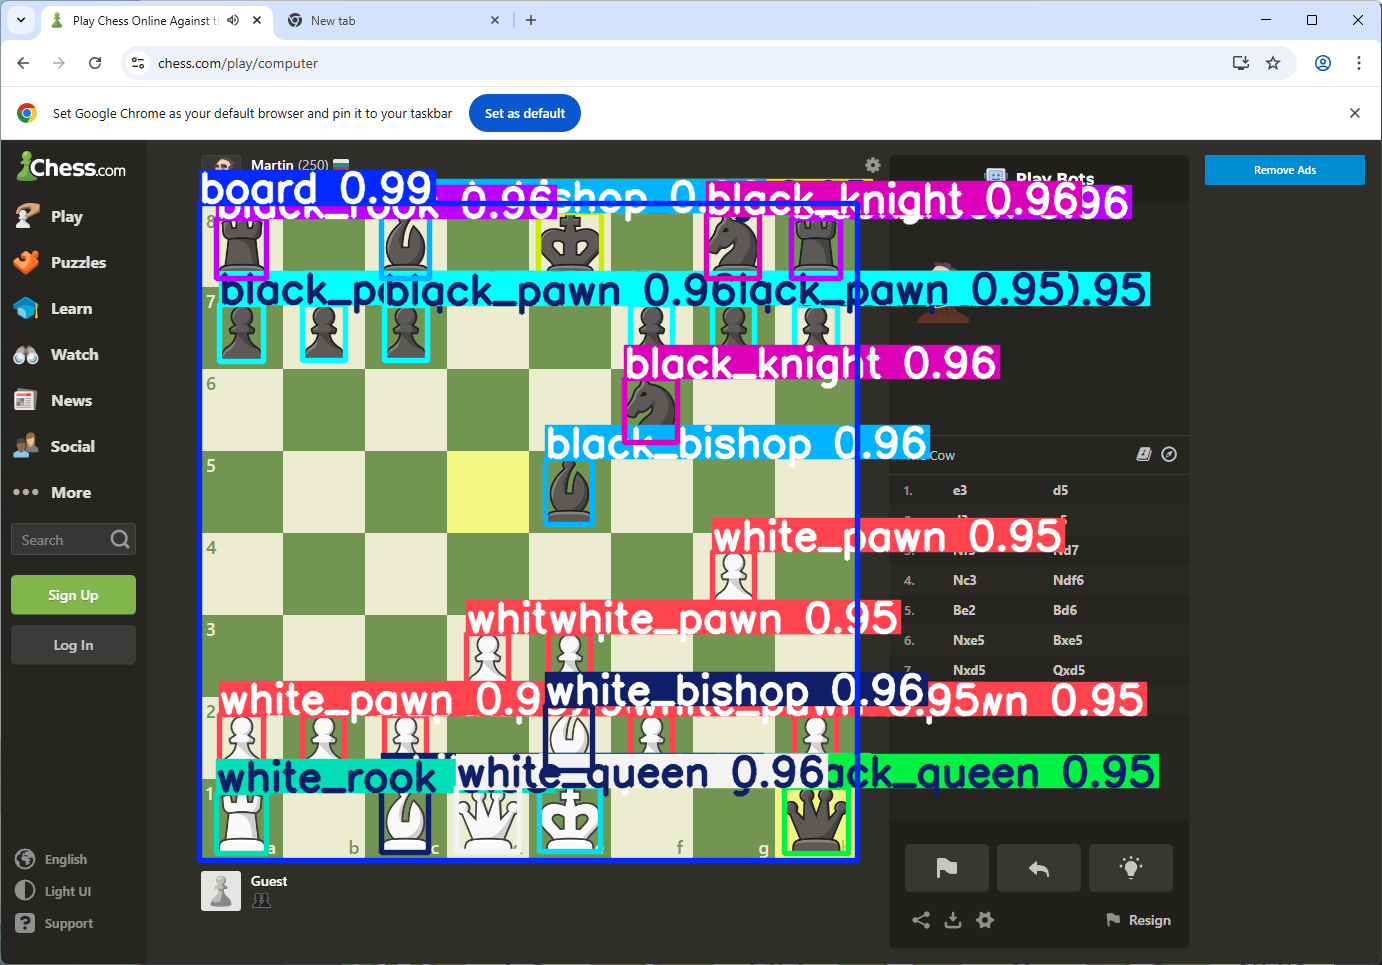

In [14]:
img_path = "data/browserscreenshots/chrome_164250_as.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

the hugging face model recognizes both the board and the pieces


image 1/1 /workspace/data/browserscreenshots/Screenshot_20251115_130933_Duolingo.jpg: 832x384 1 board, 2 white_pawns, 4 black_pawns, 20.4ms
Speed: 3.0ms preprocess, 20.4ms inference, 7.3ms postprocess per image at shape (1, 3, 832, 384)


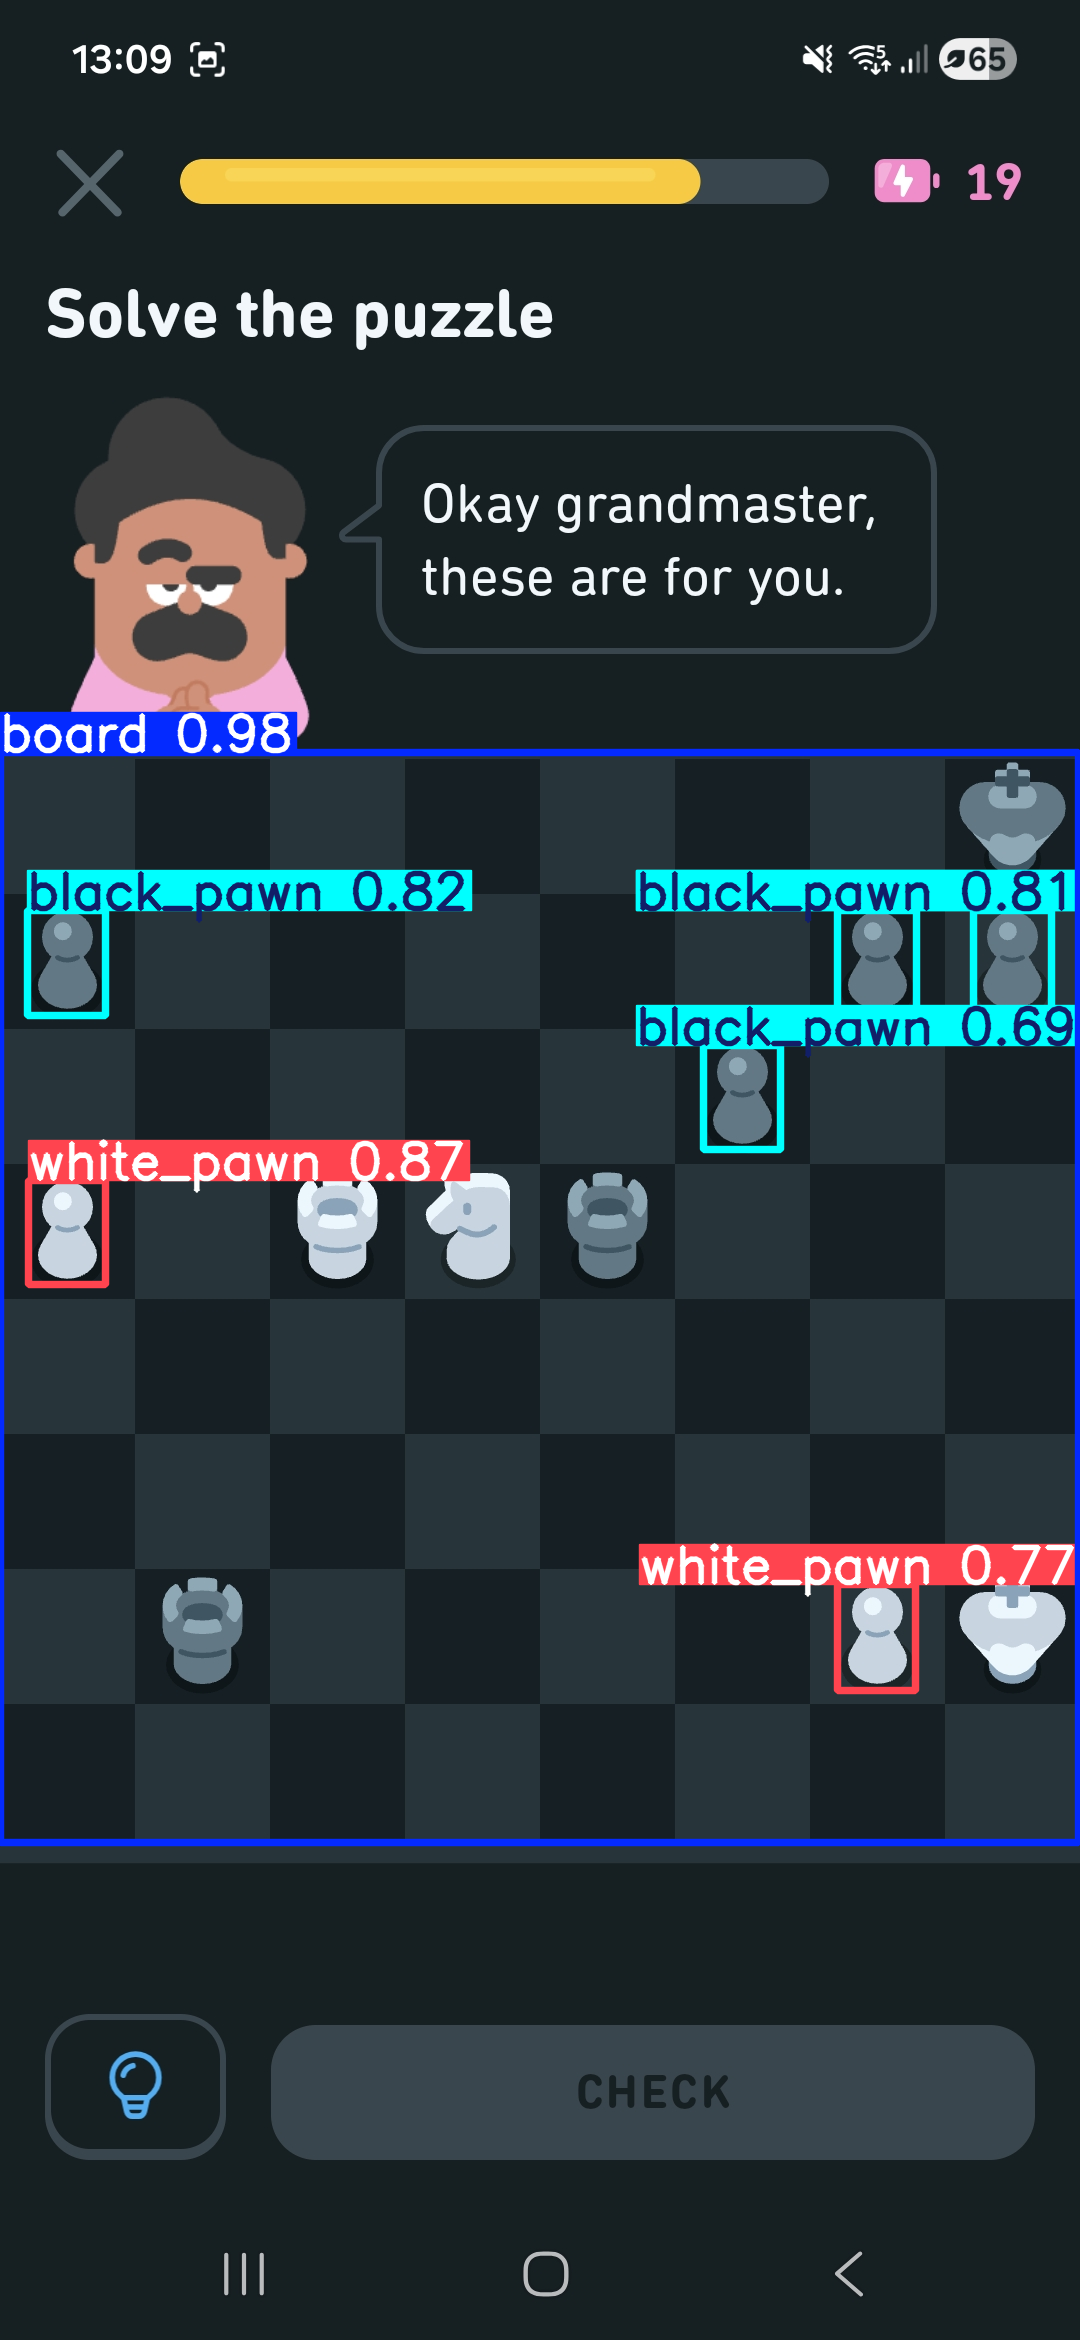

In [16]:
img_path = "data/browserscreenshots/Screenshot_20251115_130933_Duolingo.jpg"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

the rook, horse and king are not recognized.


image 1/1 /workspace/data/browserscreenshots/chrome_PLBWkMRPmF.png: 832x832 1 board, 1 white_king, 1 white_queen, 2 white_rooks, 2 white_bishops, 2 white_knights, 8 white_pawns, 1 black_king, 1 black_queen, 2 black_rooks, 2 black_bishops, 2 black_knights, 8 black_pawns, 168.4ms
Speed: 4.1ms preprocess, 168.4ms inference, 22.2ms postprocess per image at shape (1, 3, 832, 832)


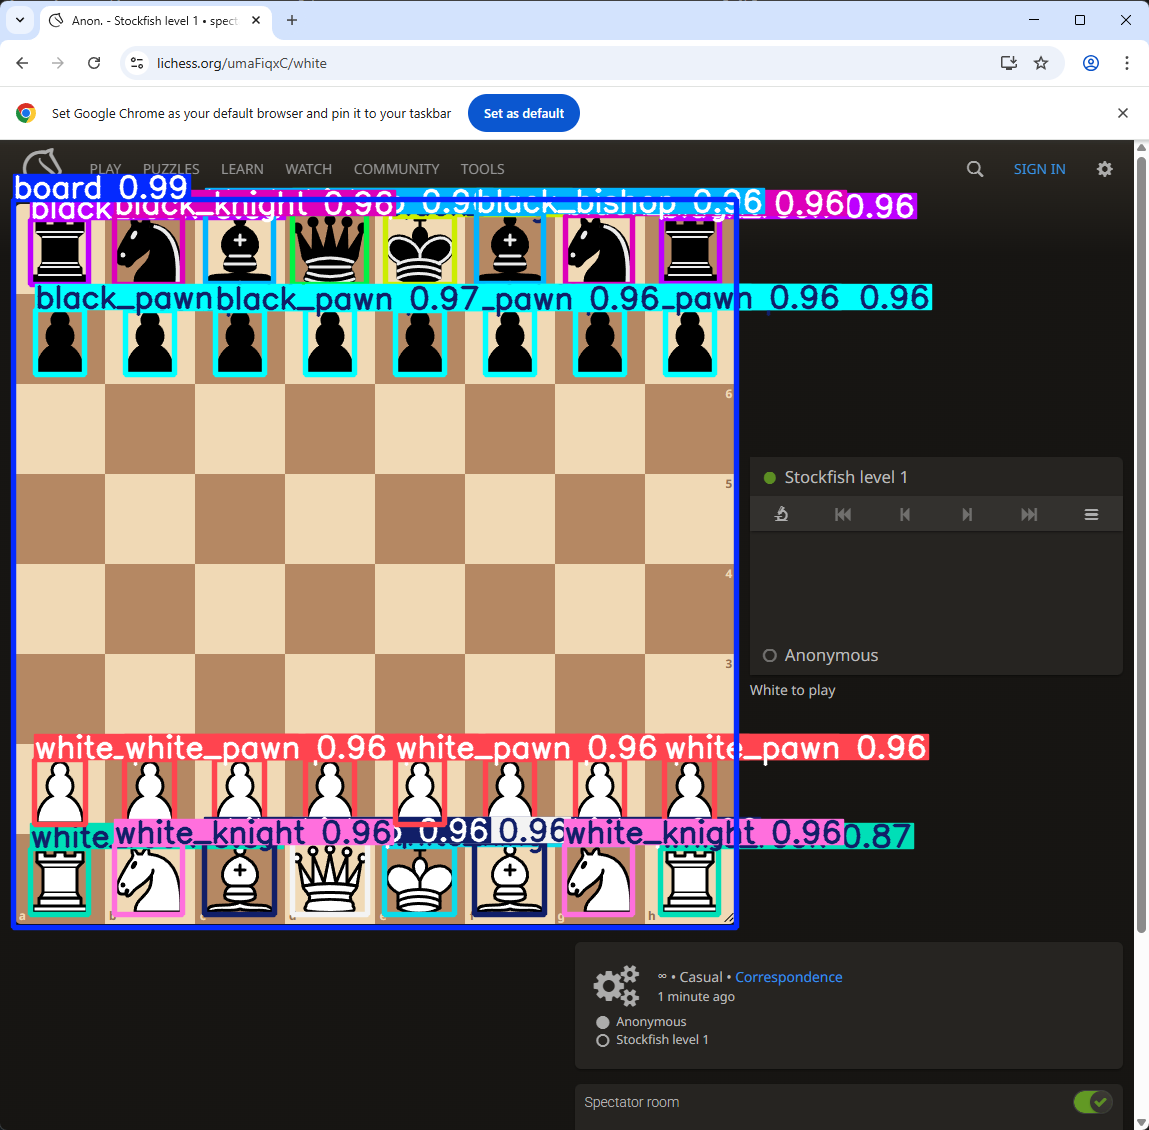

In [17]:
img_path = "data/browserscreenshots/chrome_PLBWkMRPmF.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()


image 1/1 /workspace/data/browserscreenshots/chrome_8BafXl8Lrb.png: 832x832 1 board, 2 white_kings, 2 white_queens, 3 white_rooks, 3 white_bishops, 3 white_knights, 8 white_pawns, 2 black_kings, 2 black_queens, 3 black_rooks, 3 black_bishops, 3 black_knights, 9 black_pawns, 164.0ms
Speed: 4.5ms preprocess, 164.0ms inference, 32.6ms postprocess per image at shape (1, 3, 832, 832)


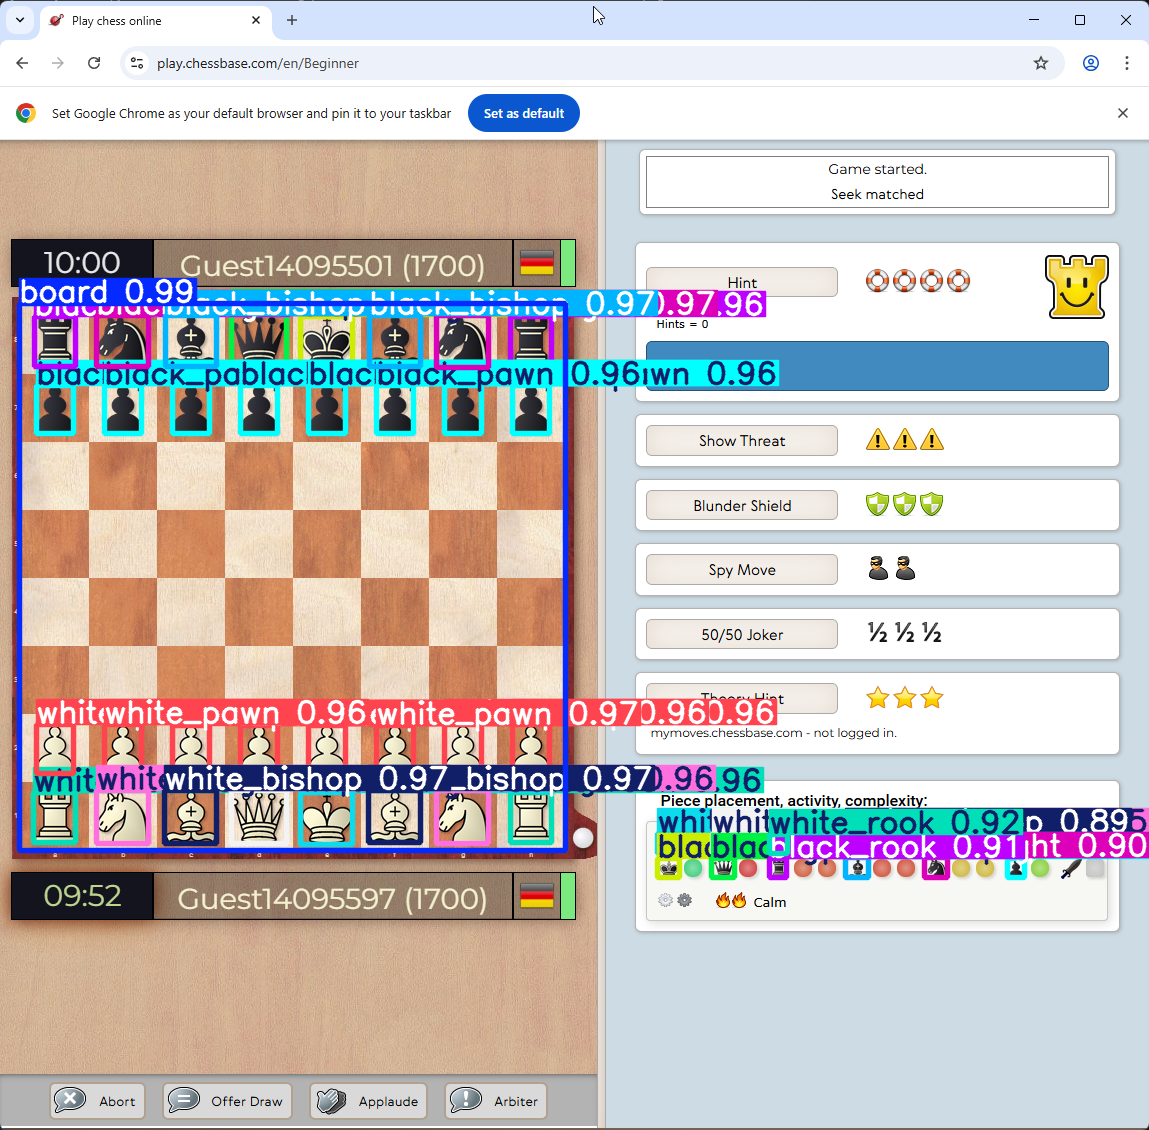

In [18]:
img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"

# Run inference
results = model.predict(img_path)  # or model.predict(img_path)
# Show results
results[0].show()

In [20]:
import numpy as np

img_path = "data/browserscreenshots/chrome_8BafXl8Lrb.png"
results = model.predict(img_path)
boxes = results[0].boxes
class_names = results[0].names

# Map class names to symbols
piece_symbols = {
    "white_king": "K", "white_queen": "Q", "white_rook": "R", "white_bishop": "B", "white_knight": "N", "white_pawn": "P",
    "black_king": "k", "black_queen": "q", "black_rook": "r", "black_bishop": "b", "black_knight": "n", "black_pawn": "p",
    "board": "."
}

# Find board bounding box
board_box = None
for box in boxes:
    cls_id = int(box.cls)
    if class_names[cls_id] == "board":
        board_box = box.xyxy[0].tolist()
        break

if board_box is None:
    print("No board detected.")
else:
    x1, y1, x2, y2 = board_box
    board_w = x2 - x1
    board_h = y2 - y1

    # Prepare empty board
    board = [["." for _ in range(8)] for _ in range(8)]

    # Place pieces
    for box in boxes:
        cls_id = int(box.cls)
        name = class_names[cls_id]
        if name == "board":
            continue
        # Get center of bounding box
        bx1, by1, bx2, by2 = box.xyxy[0].tolist()
        cx = (bx1 + bx2) / 2
        cy = (by1 + by2) / 2
        # Map to board square
        col = int(8 * (cx - x1) / board_w)
        row = int(8 * (cy - y1) / board_h)
        # Clamp to board
        col = min(max(col, 0), 7)
        row = min(max(row, 0), 7)
        # Place symbol
        board[row][col] = piece_symbols.get(name, "?")

    # Print board (top row first)
    for row in board:
        print(" ".join(row))


image 1/1 /workspace/data/browserscreenshots/chrome_8BafXl8Lrb.png: 832x832 1 board, 2 white_kings, 2 white_queens, 3 white_rooks, 3 white_bishops, 3 white_knights, 8 white_pawns, 2 black_kings, 2 black_queens, 3 black_rooks, 3 black_bishops, 3 black_knights, 9 black_pawns, 178.8ms
Speed: 2.9ms preprocess, 178.8ms inference, 53.3ms postprocess per image at shape (1, 3, 832, 832)
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N K


## Fine-Tuning the Model with Additional Images

Yes! You can definitely improve the HuggingFace model by fine-tuning it with your own dataset. This is called **transfer learning** or **fine-tuning**. 

**Benefits of fine-tuning:**
- Better performance on your specific chess board styles (e.g., chess.com screenshots)
- Can fix issues like misclassifications (bishop as queen, etc.)
- Adapts to your specific use case while leveraging the pre-trained knowledge

**What we'll do:**
1. Use the pre-trained NAKSTStudio model as a starting point
2. Continue training it on your Grupo12 dataset
3. The model will learn to better recognize pieces in your specific images

Let's set this up!


In [ ]:
# Step 1: Check dataset structure and prepare for training
import json
from pathlib import Path
import os

print("=" * 70)
print("PREPARING DATASET FOR FINE-TUNING")
print("=" * 70)

# Check dataset paths
dataset_base = Path("data/Grupo12")
train_json = dataset_base / "train" / "_annotations.coco.json"
valid_json = dataset_base / "valid" / "_annotations.coco.json"
test_json = dataset_base / "test" / "_annotations.coco.json"

print(f"\n1. Dataset structure:")
print(f"   Train: {train_json.exists()}")
print(f"   Valid: {valid_json.exists()}")
print(f"   Test: {test_json.exists()}")

# Load and analyze training data
if train_json.exists():
    with open(train_json, 'r') as f:
        train_data = json.load(f)
    
    print(f"\n2. Training dataset info:")
    print(f"   Images: {len(train_data['images'])}")
    print(f"   Annotations: {len(train_data['annotations'])}")
    print(f"   Categories: {len(train_data['categories'])}")
    
    # Show categories
    print(f"\n3. Categories in dataset:")
    for cat in train_data['categories']:
        print(f"   ID {cat['id']}: {cat['name']}")
    
    # Check if categories match model classes
    print(f"\n4. Category matching with model:")
    model_classes = set(model.names.values())
    dataset_classes = set([cat['name'] for cat in train_data['categories']])
    
    matching = model_classes.intersection(dataset_classes)
    missing_in_dataset = model_classes - dataset_classes
    extra_in_dataset = dataset_classes - model_classes
    
    print(f"   Matching classes: {len(matching)}")
    if matching:
        print(f"      {sorted(matching)}")
    if missing_in_dataset:
        print(f"   Missing in dataset (model has but dataset doesn't): {sorted(missing_in_dataset)}")
    if extra_in_dataset:
        print(f"   Extra in dataset (dataset has but model doesn't): {sorted(extra_in_dataset)}")
    
    print(f"\n✓ Dataset is ready for fine-tuning!")
else:
    print("⚠ Training dataset not found!")


In [ ]:
# Step 2: Convert COCO format to YOLO format (required for YOLOv8 training)
# YOLOv8 requires YOLO format: one .txt file per image with normalized coordinates

from pathlib import Path
import json
import shutil

print("=" * 70)
print("CONVERTING COCO TO YOLO FORMAT")
print("=" * 70)

def convert_coco_to_yolo(coco_json_path, images_dir, output_dir, class_mapping):
    """
    Convert COCO format annotations to YOLO format.
    
    Args:
        coco_json_path: Path to COCO JSON file
        images_dir: Directory containing images
        output_dir: Output directory for YOLO format
        class_mapping: Dict mapping COCO category names to YOLO class IDs
    """
    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load COCO data
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    # Create image ID to filename mapping
    image_id_to_info = {img['id']: img for img in coco_data['images']}
    
    # Group annotations by image
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)
    
    # Process each image
    converted_count = 0
    for img_id, img_info in image_id_to_info.items():
        img_filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']
        
        # Find corresponding image file
        img_path = Path(images_dir) / img_filename
        if not img_path.exists():
            continue
        
        # Create YOLO annotation file
        txt_filename = Path(img_filename).stem + '.txt'
        txt_path = output_dir / txt_filename
        
        # Get annotations for this image
        annotations = annotations_by_image.get(img_id, [])
        
        # Write YOLO format annotations
        with open(txt_path, 'w') as f:
            for ann in annotations:
                category_id = ann['category_id']
                # Find category name
                category_name = None
                for cat in coco_data['categories']:
                    if cat['id'] == category_id:
                        category_name = cat['name']
                        break
                
                if category_name is None:
                    continue
                
                # Map to YOLO class ID
                yolo_class_id = class_mapping.get(category_name)
                if yolo_class_id is None:
                    # Skip if category not in mapping
                    continue
                
                # Get bounding box (COCO format: [x, y, width, height])
                bbox = ann['bbox']
                x, y, w, h = bbox
                
                # Convert to YOLO format (normalized center coordinates)
                x_center = (x + w / 2) / img_width
                y_center = (y + h / 2) / img_height
                width_norm = w / img_width
                height_norm = h / img_height
                
                # Write to file: class_id x_center y_center width height
                f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")
        
        # Copy image to output directory
        shutil.copy2(img_path, output_dir / img_filename)
        converted_count += 1
    
    return converted_count

# Create class mapping from COCO category names to model class IDs
# We need to map the dataset categories to the model's class IDs
print("\n1. Creating class mapping...")

# Load training data to get categories
with open(train_json, 'r') as f:
    train_data = json.load(f)

# Get model class names (ID -> name)
model_class_id_to_name = model.names
model_name_to_id = {name: class_id for class_id, name in model_class_id_to_name.items()}

# Create mapping from COCO category names to YOLO class IDs
class_mapping = {}
for cat in train_data['categories']:
    coco_name = cat['name']
    # Try to find matching model class
    # Handle different naming conventions
    coco_lower = coco_name.lower()
    
    # Direct match
    if coco_name in model_name_to_id:
        class_mapping[coco_name] = model_name_to_id[coco_name]
    # Try case-insensitive match
    elif coco_lower in {k.lower(): v for k, v in model_name_to_id.items()}:
        for model_name, model_id in model_name_to_id.items():
            if model_name.lower() == coco_lower:
                class_mapping[coco_name] = model_id
                break
    # Special case: "Chess-pieces" might be a generic category
    elif coco_name == "Chess-pieces":
        # Skip this generic category
        continue
    else:
        print(f"   Warning: Could not map '{coco_name}' to model class")

print(f"   Mapped {len(class_mapping)} categories:")
for coco_name, yolo_id in sorted(class_mapping.items()):
    model_class_name = model_class_id_to_name[yolo_id]
    print(f"      {coco_name} -> {yolo_id} ({model_class_name})")

# Convert datasets
print("\n2. Converting datasets...")
yolo_base = Path("data/Grupo12_yolo")
yolo_base.mkdir(exist_ok=True)

for split in ['train', 'valid', 'test']:
    split_json = dataset_base / split / "_annotations.coco.json"
    split_images = dataset_base / split
    split_output = yolo_base / split
    
    if split_json.exists():
        print(f"\n   Converting {split}...")
        count = convert_coco_to_yolo(split_json, split_images, split_output, class_mapping)
        print(f"      Converted {count} images")
    else:
        print(f"\n   Skipping {split} (not found)")

print(f"\n✓ Conversion complete! YOLO format dataset at: {yolo_base}")


In [ ]:
# Step 3: Create dataset configuration file (YOLOv8 requires a YAML config)
import yaml

print("=" * 70)
print("CREATING DATASET CONFIGURATION")
print("=" * 70)

# Create dataset YAML file
dataset_config = {
    'path': str(Path("data/Grupo12_yolo").absolute()),
    'train': 'train',
    'val': 'valid',
    'test': 'test',
    'nc': len(model.names),  # Number of classes
    'names': list(model.names.values())  # Class names in order
}

config_path = Path("data/Grupo12_yolo/dataset.yaml")
with open(config_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, sort_keys=False)

print(f"\n✓ Dataset config created: {config_path}")
print(f"\nConfig contents:")
print(f"   Path: {dataset_config['path']}")
print(f"   Train: {dataset_config['train']}")
print(f"   Val: {dataset_config['val']}")
print(f"   Test: {dataset_config['test']}")
print(f"   Classes: {dataset_config['nc']}")
print(f"   Names: {dataset_config['names']}")


In [8]:
auto_annotate_for_cvat(
    model=model,
    input_dir="data/browserscreenshots",
    output_dir="data/auto_annotated_browserscreenshots",
    conf_threshold=0.25
)

Found 59 images to annotate

Processing images...


  0%|                                                                                            | 0/59 [00:00<?, ?it/s]/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /pytorch/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)
100%|███████████████████████████████████████████████████████████████████████████████████| 59/59 [00:10<00:00,  5.84it/s]


✓ Annotation complete!
  Images: 59
  Annotations: 1420
  Output: data/auto_annotated_browserscreenshots
  COCO JSON: data/auto_annotated_browserscreenshots/_annotations.coco.json

📋 Next steps:
  1. Import '_annotations.coco.json' into CVAT
  2. Review and correct annotations in CVAT
  3. Export corrected annotations from CVAT
  4. Use for training!
